<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica Aplicada I 

## ANÁLISE DE VIGAS

### Problema 3

Na figura está representada uma viga AB ligada a um apoio fixo em A e a um apoio móvel em B. A viga suporta uma carga distribuída linear $Q(x)$ aplicada entre A e B. No referencial indicado na figura considere $Q(x = 0) = 10$ kN/m e $Q(x = 5) = 15$ kN/m.

a) Determine por integração a coordenada $x$ do centroide da superfície delimitada pela função representando a carga distribuída aplicada sobre a viga.

b) Calcule as reações nos apoios A e B.

c) Escreva as equações do esforço transverso e do momento fletor na viga e trace os respetivos diagramas.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P3/MAI_Ch08_P3.png"
width="500">


In [56]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

# Dados | Unidades: m, kN/m
L, QA, QB = 5., 10., 15.


### Resumo

#### a) Determine por integração a coordenada $x$ do centroide da superfície delimitada pela função representando a carga distribuída aplicada sobre a viga.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P3/MAI_Ch08_P3a.png"
width="600">

- Equação $Q(x)$


In [57]:
q, x = sy.symbols('q x')

A = (0,QA)
B = (L,QB)

def q(y,A,B):
    m = (B[1]-B[0])/(A[1]-A[0])
    return A[1] + m*(y - A[0])

Q = q(x,A,B)
print(f'Q(x) = {Q} kN/m')


Q(x) = 1.0*x + 10.0 kN/m


A força equivalente $P_{eq}$ do carregamento aplicado representa a área distribuida:

\begin{equation*}
Q_{eq} \equiv A = \int_{0}^L \left( \int_{0}^{Q(x)}~\mathrm{d}y\right)\mathrm{d}x = \int_{0}^L Q(x)~\mathrm{d}x
\end{equation*}

O ponto de aplicação da força é o centróide da área definida pela curva $Q(x)$. O valor do centróide pode ser calculado de acordo com a expressão:

\begin{equation*}
\overline{x} = \frac{Q_y}{A}
\quad\wedge\quad
Q_y = \int_0^L Q(x)x~\mathrm{d}x
\quad\wedge\quad
A = \int_0^L Q(x)\mathrm{d}x
\end{equation*}


In [58]:
Qeq = sy.integrate(Q, (x,0,L)) # forca resultante equivalente
print(f'  Qeq = {Qeq:.2f} [kN]')
Qy = sy.integrate(Q*x, (x,0,L))
print(f'   Qy = {Qy:.2f} [kN/m]')
A = Qeq
print(f'    A = Qeq = {A:.2f} [m2]')
xcent = Qy/A
print(f'xcent = {sy.N(xcent):.3f} [m]')

  Qeq = 62.50 [kN]
   Qy = 166.67 [kN/m]
    A = Qeq = 62.50 [m2]
xcent = 2.667 [m]


#### b) Calcule as reações nos apoios A e B.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P3/MAI_Ch08_P3b.png"
width="600">

In [59]:

print('Sistema de equações')
print('-------------------')
rax, ray, rby = sy.symbols('rax ray rby')

sumFx = rax
print('Sum Fx :',sumFx)
sumFy = ray + rby - Qeq
print('Sum Fy :',sumFy)
sumMA =  -Qeq*xcent + rby*L
print('Sum sumMA :',printsymSF(sumMA))
sol = solve({sumFx,sumFy, sumMA},{rax, ray, rby})

Sistema de equações
-------------------
Sum Fx : rax
Sum Fy : ray + rby - 62.5
Sum sumMA : 5.0*rby - 166.667


In [60]:
print('-------------------')
print('Reações')
print('-------------------')
RAx, RAy, RBy = sol[rax], sol[ray], sol[rby]
print(f'RAx  = {RAx:.2f} [kN]')
print(f'RAy  = {RAy:.2f} [kN]')
print(f'MB   = {RBy:.2f} [kN]')

-------------------
Reações
-------------------
RAx  = 0.00 [kN]
RAy  = 29.17 [kN]
MB   = 33.33 [kN]


#### c) Escreva as equações do esforço transverso e do momento fletor na viga e trace os respetivos diagramas.

Para definir os esforços internos da viga deve-se usar o método das secções. Na aplicação deste método, considere-se um corte interno entre os pontos A e B, onde o domínio $x$ varia entre 0 e 5 m. No diagrama de corpo livre na secção resultante à esquerda, surbem esforços internos como ilustrados na figura, correspondentes ao esforço normal, $N(x)$, esforço transverso, $V(x)$, e momento flector da viga, $M(x)$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P3/MAI_Ch08_P3c.png"
width="600">

\begin{equation*}
V(x) - V_A = -\int_0^x Q(x) \mathrm{d}x =  R_{Ay} -\int_0^x Q(x) \mathrm{d}x
\end{equation*}

In [61]:
v = sy.symbols('v')

print('Esforço tranverso')
print('-------------------')

VA = RAy
eqV = v - VA + sy.integrate(Q, (x,0,x))
sol = solve({eqV},{v})
Vx = sol[v]
print(f'V(x) = {printsymSF(Vx)} [kN]')

Esforço tranverso
-------------------
V(x) = -0.5*x**2 - 10.0*x + 29.167 [kN]


\begin{equation*}
M(x) - M_A = \int_0^x V(x) \mathrm{d}x = 0 + \int_0^x V(x) \mathrm{d}x
\end{equation*}

In [62]:
m = sy.symbols('m')

print('Momento fletor')
print('-------------------')

MA = 0
eqM = m - sy.integrate(Vx, (x,0,x))
sol = solve({eqM},{m})
Mx = sol[m]
print(f'M(x) = {Mx} [kN.m]')

Momento fletor
-------------------
M(x) = -0.166666666666667*x**3 - 5.0*x**2 + 29.1666666666667*x [kN.m]


In [63]:
sol = solve(Vx,x)
x_mmax = sol[1]
print('Coordenada para o momento fletor máximo correspondente a esforço transverso nulo:')
print(f'x_mmax = {x_mmax:.3f} [m]')

Coordenada para o momento fletor máximo correspondente a esforço transverso nulo:
x_mmax = 2.583 [m]


In [64]:
xp = np.linspace(0,L,1000)

def sy2array(syfunc,xlist):
    scalar_func = lambda xx: float(syfunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

Vplot = sy2array(Vx,xp) #
Mplot = sy2array(Mx,xp) #

def plotesf(x,y,xman,ymax,lab1,lab2):
    plt.figure(figsize=(9,5.56))
    plt.plot(x,y,linewidth=4)
    plt.axhline(y=0, color='gray', linestyle='-')
    plt.axvline(x=0, color='gray', linestyle='-')
    plt.plot(x[0],y[0],'go',markersize=10)
    plt.text(x[0]*.85,y[0]*.96,f'({x[0]:.0f},{y[0]:.2f})',fontsize=18)
    plt.plot(x[-1],y[-1],'go',markersize=10)
    plt.text(x[-1]*.85,y[-1]*.96,f'({x[-1]:.0f},{y[-1]:.2f})',fontsize=18)
    plt.plot(xman,ymax,'go',markersize=10)
    plt.text(xman,ymax,f'({xman:.0f},{ymax:.2f})',fontsize=18)
    plt.xlabel(lab1)
    plt.ylabel(lab2)
    plt.grid(True)
    plt.show()

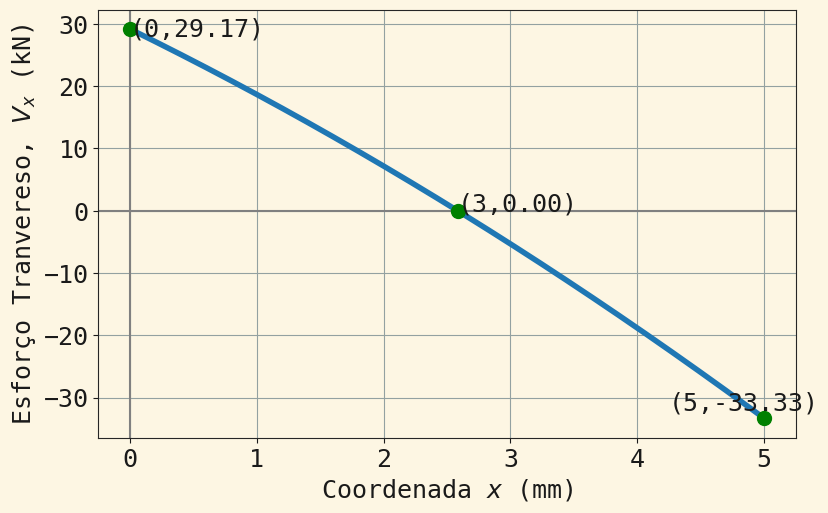

In [65]:
plotesf(xp,Vplot,x_mmax,Vx.subs(x,x_mmax),'Coordenada $x$ (mm)','Esforço Tranvereso, $V_{x}$ (kN)')

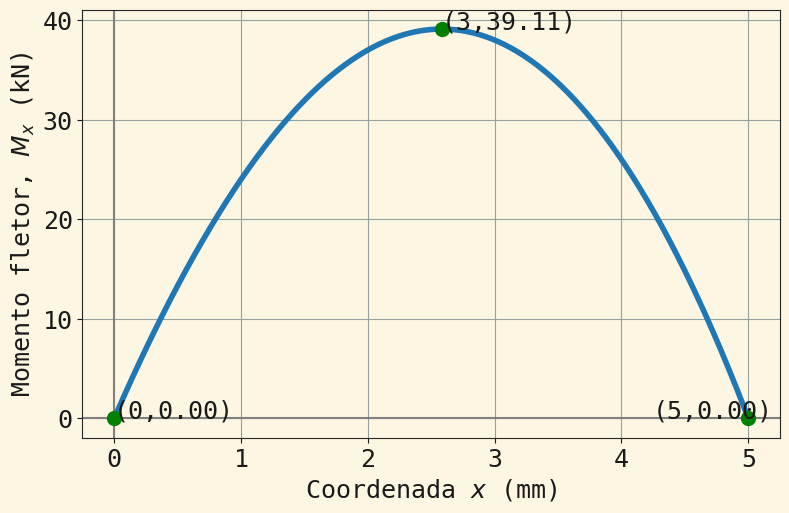

In [66]:
plotesf(xp,Mplot,x_mmax,Mx.subs(x,x_mmax),'Coordenada $x$ (mm)','Momento fletor, $M_{x}$ (kN)')

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>